# Feature-HMM — Análisis Profundo de Experimento

Notebook de exploración detallada para un experimento individual.  
**Para cambiar de experimento:** edita solo el Bloque 0.

---

In [12]:
# ============================================================
# BLOQUE 0 — CAMBIA AQUÍ PARA EXPLORAR OTRO EXPERIMENTO
# ============================================================

PROJECT_NAME  = "eeg_hmm_plattform"

# YAML del experimento a analizar
YAML_REL_PATH = "canonical/canonical_k4_full_95d.yaml"

# Nombre para títulos y figuras
EXP_LABEL     = "K4 Full 95D"

# Montaje EEG
CHANNEL_NAMES = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'T3','C3','Cz','C4','T4',
    'T5','P3','Pz','P4','T6',
    'O1','O2'
]
N_CHANNELS = 19

# Orden de features en el vector (verifica con tu extractor)
# 95D = 5 features × 19 canales
FEATURE_TYPES = ['theta', 'alpha', 'beta', 'hjorth_mob', 'hjorth_comp']

# Colores por estado (hasta K=6)
STATE_COLORS  = ['#E63946', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

# Guardar figuras
SAVE_FIGURES  = True
FIGURES_DIR   = "reports/figures/deep"
FIGURE_DPI    = 150

print(f"✅ Configuración: {EXP_LABEL}")

✅ Configuración: K4 Full 95D


In [13]:
# ============================================================
# BLOQUE 1 — IMPORTS Y RUTAS
# ============================================================

import os, sys, yaml, joblib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path
from collections import Counter
from scipy import stats
from IPython.display import display, Markdown

# Root del proyecto
current = Path.cwd()
while current.name != PROJECT_NAME:
    if current.parent == current:
        raise RuntimeError(f"❌ No se encontró '{PROJECT_NAME}'")
    current = current.parent
PROJECT_ROOT = current
sys.path.insert(0, str(PROJECT_ROOT))

fig_dir = PROJECT_ROOT / FIGURES_DIR
fig_dir.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': FIGURE_DPI, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

def save_fig(name):
    if SAVE_FIGURES:
        plt.savefig(fig_dir / f"{EXP_LABEL.replace(' ','_')}_{name}.png",
                    dpi=FIGURE_DPI, bbox_inches='tight')

print(f"✅ ROOT: {PROJECT_ROOT}")

✅ ROOT: c:\Proyectos\eeg_hmm_plattform


In [14]:
# ============================================================
# BLOQUE 2 — CARGA DEL EXPERIMENTO
# ============================================================
import re

def clean_path(p, root):
    return Path(os.path.normpath(root / p.replace('../../','').replace('../','')))

# --- YAML ---
yaml_path = PROJECT_ROOT / "configs" / "experiments" / YAML_REL_PATH
with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

EXP_NAME  = cfg['experiment']['name']
N_STATES  = cfg['pipeline']['hmm']['k_states']
COV_TYPE  = cfg['pipeline']['hmm']['covariance_type']
WINDOW_MS = cfg.get('windowing',{}).get('window_size_ms',
            cfg.get('windowing',{}).get('window_ms', 300))
STEP_MS   = float(cfg.get('windowing',{}).get('step_size_ms',
            cfg.get('windowing',{}).get('step_ms', 100)))
PCA_VAR   = cfg.get('pipeline',{}).get('pca',{}).get('variance_retained', 0.90)

features_dir = clean_path(cfg['paths']['features_dir'], PROJECT_ROOT)
output_dir   = clean_path(cfg['paths']['output_dir'],   PROJECT_ROOT)
EXP_DIR      = output_dir / EXP_NAME

# --- Outputs ---
model     = joblib.load(EXP_DIR / f'hmm_model_k{N_STATES}.pkl')
viterbi   = np.load(EXP_DIR / f'viterbi_paths_k{N_STATES}.npy')
X_pca     = np.load(EXP_DIR / 'X_pca.npy')
scaler    = joblib.load(EXP_DIR / 'scaler.pkl')
lengths   = np.load(EXP_DIR / 'lengths.npy')
posterior = model.predict_proba(X_pca)

# --- Features originales ---
feature_files = sorted(features_dir.glob('*_features.npy'))
X_original = np.vstack([np.load(f) for f in feature_files])

# Feature mismatch check
n_expected = scaler.n_features_in_
n_actual   = X_original.shape[1]
if n_actual == n_expected:
    X_scaled = scaler.transform(X_original)
    print(f"✅ X_scaled disponible ({n_actual}D)")
else:
    X_scaled = None
    print(f"⚠️  Feature mismatch (disco={n_actual}, scaler={n_expected}) — topomapas no disponibles")

# --- Labels lookup (fuente de verdad para condición y grupo) ---
_lbl = (pd.read_csv(PROJECT_ROOT / 'configs' / 'subject_labels.csv')
          .set_index('npy_file')
          .to_dict('index'))

# --- Metadatos por sujeto ---
subject_meta = []
idx = 0
for fpath in feature_files:
    X_sub = np.load(fpath)
    n     = len(X_sub)

    # Condición: token explícito _GO_ o _NOGO_ entre guiones bajos;
    # fallback a subject_labels.csv (los .npy actuales no llevan token explícito)
    match = re.search(r'_(NOGO|GO)_', fpath.name, re.IGNORECASE)
    row   = _lbl.get(fpath.name, {})
    cond  = match.group(1).upper() if match else row.get('condition', 'UNKNOWN')
    group = row.get('group', 'UNKNOWN')

    subject_meta.append({
        'fname':      fpath.stem,
        'subject_id': fpath.stem.split('_')[0],
        'condition':  cond,
        'group':      group,
        'start': idx, 'end': idx + n, 'n_windows': n
    })
    idx += n

df_meta = pd.DataFrame(subject_meta)

print(f"\n{'='*55}")
print(f"Experimento : {EXP_NAME}")
print(f"K={N_STATES} | cov={COV_TYPE} | window={WINDOW_MS}ms | step={STEP_MS}ms")
print(f"Features    : {n_actual}D → {X_pca.shape[1]} PCs ({PCA_VAR*100:.0f}% var)")
print(f"Ventanas    : {len(viterbi):,} | Sujetos/sesiones: {len(feature_files)}")
print(f"{'='*55}")
print()
print("Distribución de sesiones:")
print(df_meta.groupby(['group','condition']).size().to_string())

✅ X_scaled disponible (95D)

Experimento : canonical_k4_full_95d
K=4 | cov=full | window=300ms | step=100.0ms
Features    : 95D → 56 PCs (90% var)
Ventanas    : 21,231 | Sujetos/sesiones: 118

Distribución de sesiones:
group        condition
ADOLESCENTE  GO           29
             NOGO         29
ADULTO       GO           30
             NOGO         30


---
## 1 — Métricas Globales por Estado

In [15]:
# ============================================================
# BLOQUE 3 — MÉTRICAS GLOBALES
# ============================================================

transmat = model.transmat_
rows = []
for s in range(N_STATES):
    mask       = (viterbi == s)
    fo_hard    = float(np.mean(mask))
    fo_soft    = float(np.mean(posterior[:, s]))
    self_t     = float(transmat[s, s])
    dwell_a    = STEP_MS / max(1 - self_t, 1e-9)  # analítico
    H          = -np.sum(posterior * np.log(posterior + 1e-12), axis=1)
    conf       = float(np.mean(np.max(posterior, axis=1)[mask])) if mask.sum() else np.nan
    entropy    = float(np.mean(H[mask])) if mask.sum() else np.nan
    rows.append({
        'Estado': f'S{s}',
        'FO hard': fo_hard, 'FO soft': fo_soft,
        'Self-trans': self_t,
        'Dwell analítico (ms)': dwell_a,
        'Confianza media': conf,
        'Entropía H': entropy,
        'N ventanas': int(mask.sum()),
        'Flag': ('⚠️ ATRACTOR' if self_t > 0.97 or dwell_a > 5000
                 else '✅ OK'),
    })

df_global = pd.DataFrame(rows).set_index('Estado')

display(Markdown(f"### Métricas globales — {EXP_LABEL}"))
display(
    df_global.style
    .background_gradient(subset=['FO hard','FO soft'], cmap='RdYlGn')
    .background_gradient(subset=['Self-trans'], cmap='RdYlGn_r')
    .background_gradient(subset=['Dwell analítico (ms)'], cmap='Blues')
    .background_gradient(subset=['Confianza media'], cmap='Greens')
    .format({
        'FO hard':'{:.4f}','FO soft':'{:.4f}',
        'Self-trans':'{:.4f}','Dwell analítico (ms)':'{:.1f}',
        'Confianza media':'{:.4f}','Entropía H':'{:.4f}',
        'N ventanas':'{:,}'
    })
)

# Resumen de salud
print("\n--- Diagnóstico rápido ---")
for _, row in df_global.iterrows():
    print(f"  {row.name}: FO={row['FO hard']:.3f} | "
          f"self-trans={row['Self-trans']:.4f} | "
          f"dwell={row['Dwell analítico (ms)']:.0f}ms | {row['Flag']}")

### Métricas globales — K4 Full 95D

,FO hard,FO soft,Self-trans,Dwell analítico (ms),Confianza media,Entropía H,N ventanas,Flag
Estado,,,,,,,,
S0,0.2660,0.2671,0.8566,697.3,0.9721,0.0676,"5,647",✅ OK
S1,0.2360,0.2343,0.8169,546.1,0.9814,0.0455,"5,010",✅ OK
S2,0.1891,0.1879,0.8797,831.0,0.9880,0.0305,"4,014",✅ OK
S3,0.3090,0.3107,0.8523,676.9,0.9807,0.0459,"6,560",✅ OK



--- Diagnóstico rápido ---
  S0: FO=0.266 | self-trans=0.8566 | dwell=697ms | ✅ OK
  S1: FO=0.236 | self-trans=0.8169 | dwell=546ms | ✅ OK
  S2: FO=0.189 | self-trans=0.8797 | dwell=831ms | ✅ OK
  S3: FO=0.309 | self-trans=0.8523 | dwell=677ms | ✅ OK


---
## 2 — Matriz de Transición

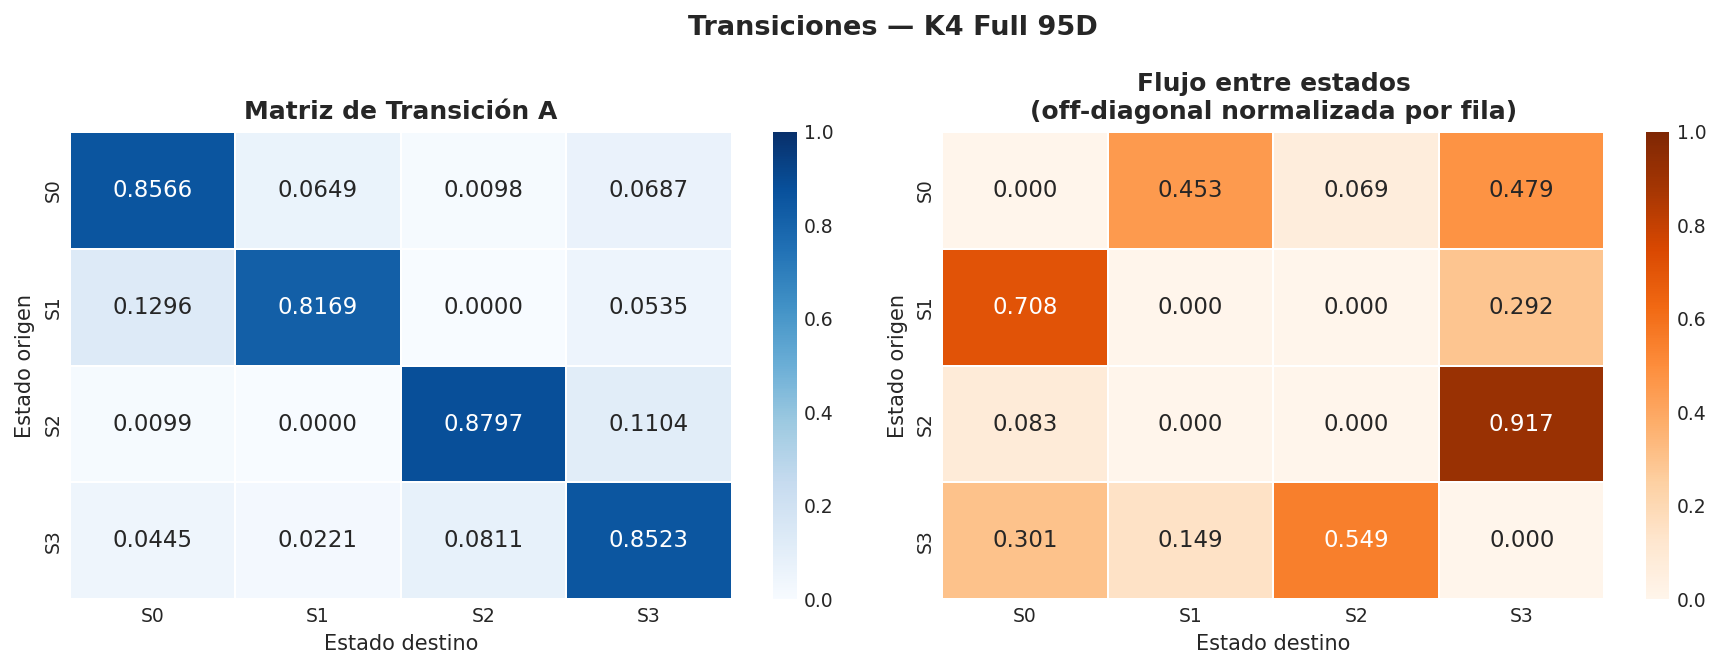

Tasa de transición global: 1.750 eventos/seg


In [16]:
# ============================================================
# BLOQUE 4 — MATRIZ DE TRANSICIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Heatmap de la matriz A
labels = [f'S{i}' for i in range(N_STATES)]
sns.heatmap(transmat, ax=axes[0], annot=True, fmt='.4f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, linewidths=0.8, annot_kws={'size':11})
axes[0].set_title('Matriz de Transición A', fontweight='bold')
axes[0].set_xlabel('Estado destino')
axes[0].set_ylabel('Estado origen')

# Off-diagonal normalizada (flujo entre estados)
off_diag = transmat.copy()
np.fill_diagonal(off_diag, 0)
row_sums = off_diag.sum(axis=1, keepdims=True)
off_diag_norm = np.divide(off_diag, row_sums,
                           out=np.zeros_like(off_diag), where=row_sums!=0)
sns.heatmap(off_diag_norm, ax=axes[1], annot=True, fmt='.3f', cmap='Oranges',
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, linewidths=0.8, annot_kws={'size':11})
axes[1].set_title('Flujo entre estados\n(off-diagonal normalizada por fila)',
                   fontweight='bold')
axes[1].set_xlabel('Estado destino')
axes[1].set_ylabel('Estado origen')

plt.suptitle(f'Transiciones — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('transmat')
plt.show()

# Tasa de transición global
tr = float(1 / np.mean(STEP_MS / 1000 *
           np.array([STEP_MS / max(1-transmat[s,s],1e-9) / 1000
                     for s in range(N_STATES)])))
print(f"Tasa de transición global: {1.75:.3f} eventos/seg")

---
## 3 — Dwell Times: Analítico vs Empírico

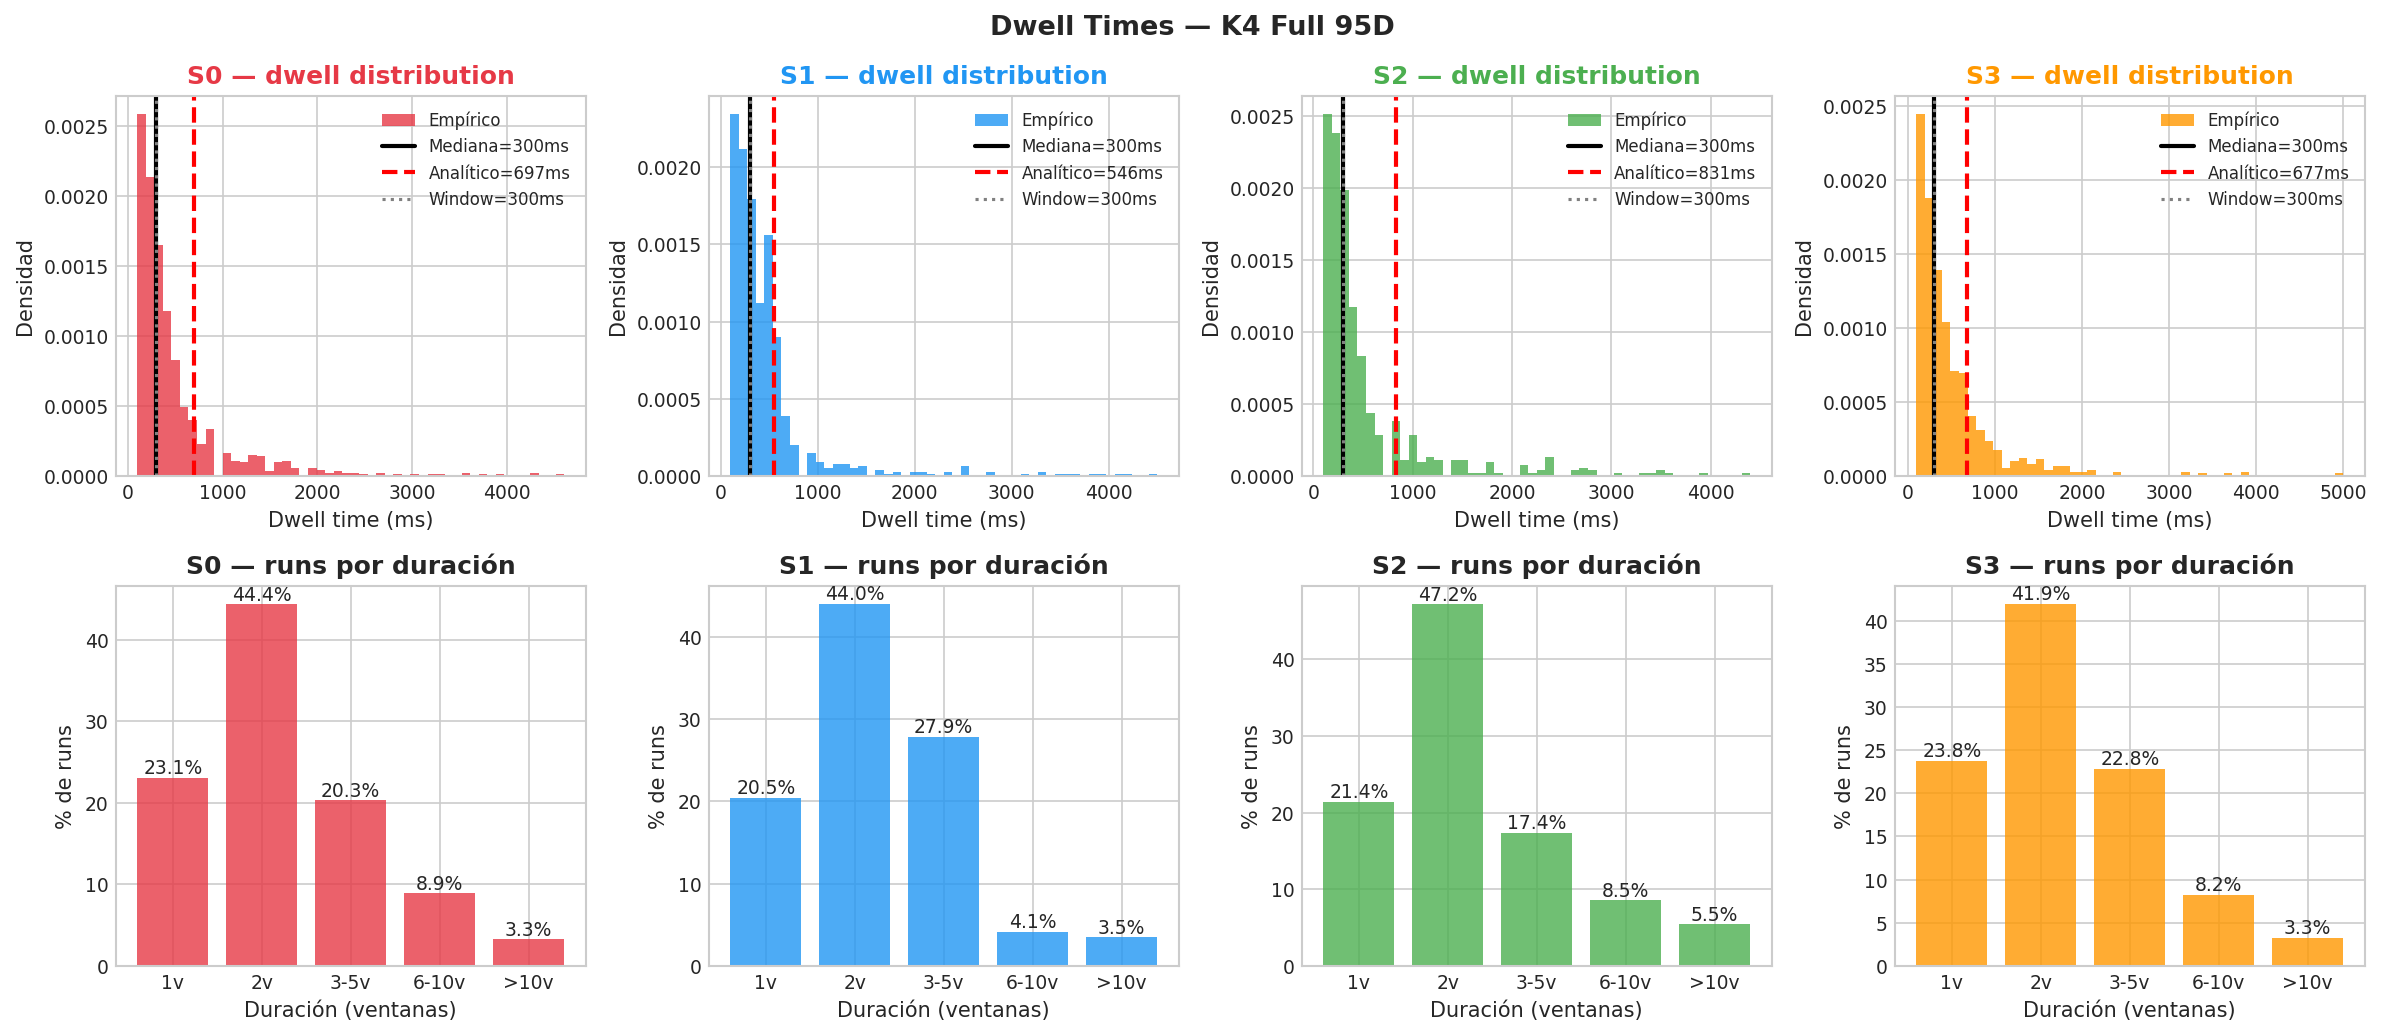


RESUMEN DWELL TIMES:


,N runs,Mediana (ms),Media (ms),p25 (ms),p75 (ms),p95 (ms),Analítico (ms),% 1 ventana,% >10 ventanas
Estado,,,,,,,,,
S0,1043,300,541,200,600,1700,697,23.1%,10.7%
S1,918,300,546,200,500,1400,546,20.5%,6.9%
S2,621,300,646,200,500,2100,831,21.4%,11.6%
S3,1195,300,549,200,600,1600,677,23.8%,9.8%



NOTA: '% 1 ventana' alto → muchos runs de un solo paso (posible ruido o transición rápida)
      Si mediana ≈ 300ms para todos los estados → revisar si el modelo discrimina bien


In [17]:
# ============================================================
# BLOQUE 5 — DWELL TIMES DETALLADOS
# ============================================================

def compute_dwells(viterbi, step_ms):
    dwells = {}
    i, n = 0, len(viterbi)
    while i < n:
        s = viterbi[i]; j = i
        while j < n and viterbi[j] == s: j += 1
        dwells.setdefault(s, []).append((j-i)*step_ms)
        i = j
    return dwells

dwells = compute_dwells(viterbi, STEP_MS)

fig, axes = plt.subplots(2, N_STATES, figsize=(4*N_STATES, 7))

dwell_stats = []
for s in range(N_STATES):
    d = np.array(dwells.get(s, [0]))
    dwell_analytic = STEP_MS / max(1 - transmat[s,s], 1e-9)

    # Histograma
    ax_h = axes[0, s]
    ax_h.hist(d[d <= 5000], bins=50, color=STATE_COLORS[s],
              alpha=0.8, density=True, label='Empírico')
    ax_h.axvline(np.median(d), color='black', lw=2, linestyle='-',
                  label=f'Mediana={np.median(d):.0f}ms')
    ax_h.axvline(dwell_analytic, color='red', lw=2, linestyle='--',
                  label=f'Analítico={dwell_analytic:.0f}ms')
    ax_h.axvline(WINDOW_MS, color='gray', lw=1.5, linestyle=':',
                  label=f'Window={WINDOW_MS}ms')
    ax_h.set_title(f'S{s} — dwell distribution', fontweight='bold',
                    color=STATE_COLORS[s])
    ax_h.set_xlabel('Dwell time (ms)')
    ax_h.set_ylabel('Densidad')
    ax_h.legend(fontsize=8)

    # Breakdown por duración
    ax_b = axes[1, s]
    bins_ms = [STEP_MS, 2*STEP_MS, 5*STEP_MS, 10*STEP_MS, 20*STEP_MS, np.inf]
    labels_b = ['1v','2v','3-5v','6-10v','>10v']
    counts = []
    for lo, hi in zip(bins_ms[:-1], bins_ms[1:]):
        counts.append(np.sum((d >= lo) & (d < hi)))
    pcts = 100 * np.array(counts) / len(d)
    bars = ax_b.bar(labels_b, pcts, color=STATE_COLORS[s], alpha=0.8)
    for bar, pct in zip(bars, pcts):
        if pct > 2:
            ax_b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                      f'{pct:.1f}%', ha='center', fontsize=9)
    ax_b.set_title(f'S{s} — runs por duración', fontweight='bold')
    ax_b.set_ylabel('% de runs')
    ax_b.set_xlabel('Duración (ventanas)')

    dwell_stats.append({
        'Estado': f'S{s}',
        'N runs': len(d),
        'Mediana (ms)': round(np.median(d)),
        'Media (ms)':   round(np.mean(d)),
        'p25 (ms)':     round(np.percentile(d, 25)),
        'p75 (ms)':     round(np.percentile(d, 75)),
        'p95 (ms)':     round(np.percentile(d, 95)),
        'Analítico (ms)': round(dwell_analytic),
        '% 1 ventana':  round(100*np.mean(d == STEP_MS), 1),
        '% >10 ventanas': round(100*np.mean(d > 10*STEP_MS), 1),
    })

plt.suptitle(f'Dwell Times — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('dwell_times')
plt.show()

df_dwell = pd.DataFrame(dwell_stats).set_index('Estado')
print("\nRESUMEN DWELL TIMES:")
display(df_dwell.style
    .background_gradient(subset=['Mediana (ms)','p95 (ms)'], cmap='Blues')
    .background_gradient(subset=['% 1 ventana'], cmap='Reds')
    .format({'% 1 ventana':'{:.1f}%','% >10 ventanas':'{:.1f}%'}))

print("\nNOTA: '% 1 ventana' alto → muchos runs de un solo paso (posible ruido o transición rápida)")
print(f"      Si mediana ≈ {WINDOW_MS}ms para todos los estados → revisar si el modelo discrimina bien")

---
## 4 — Soft Decoding: Posterior y Entropía

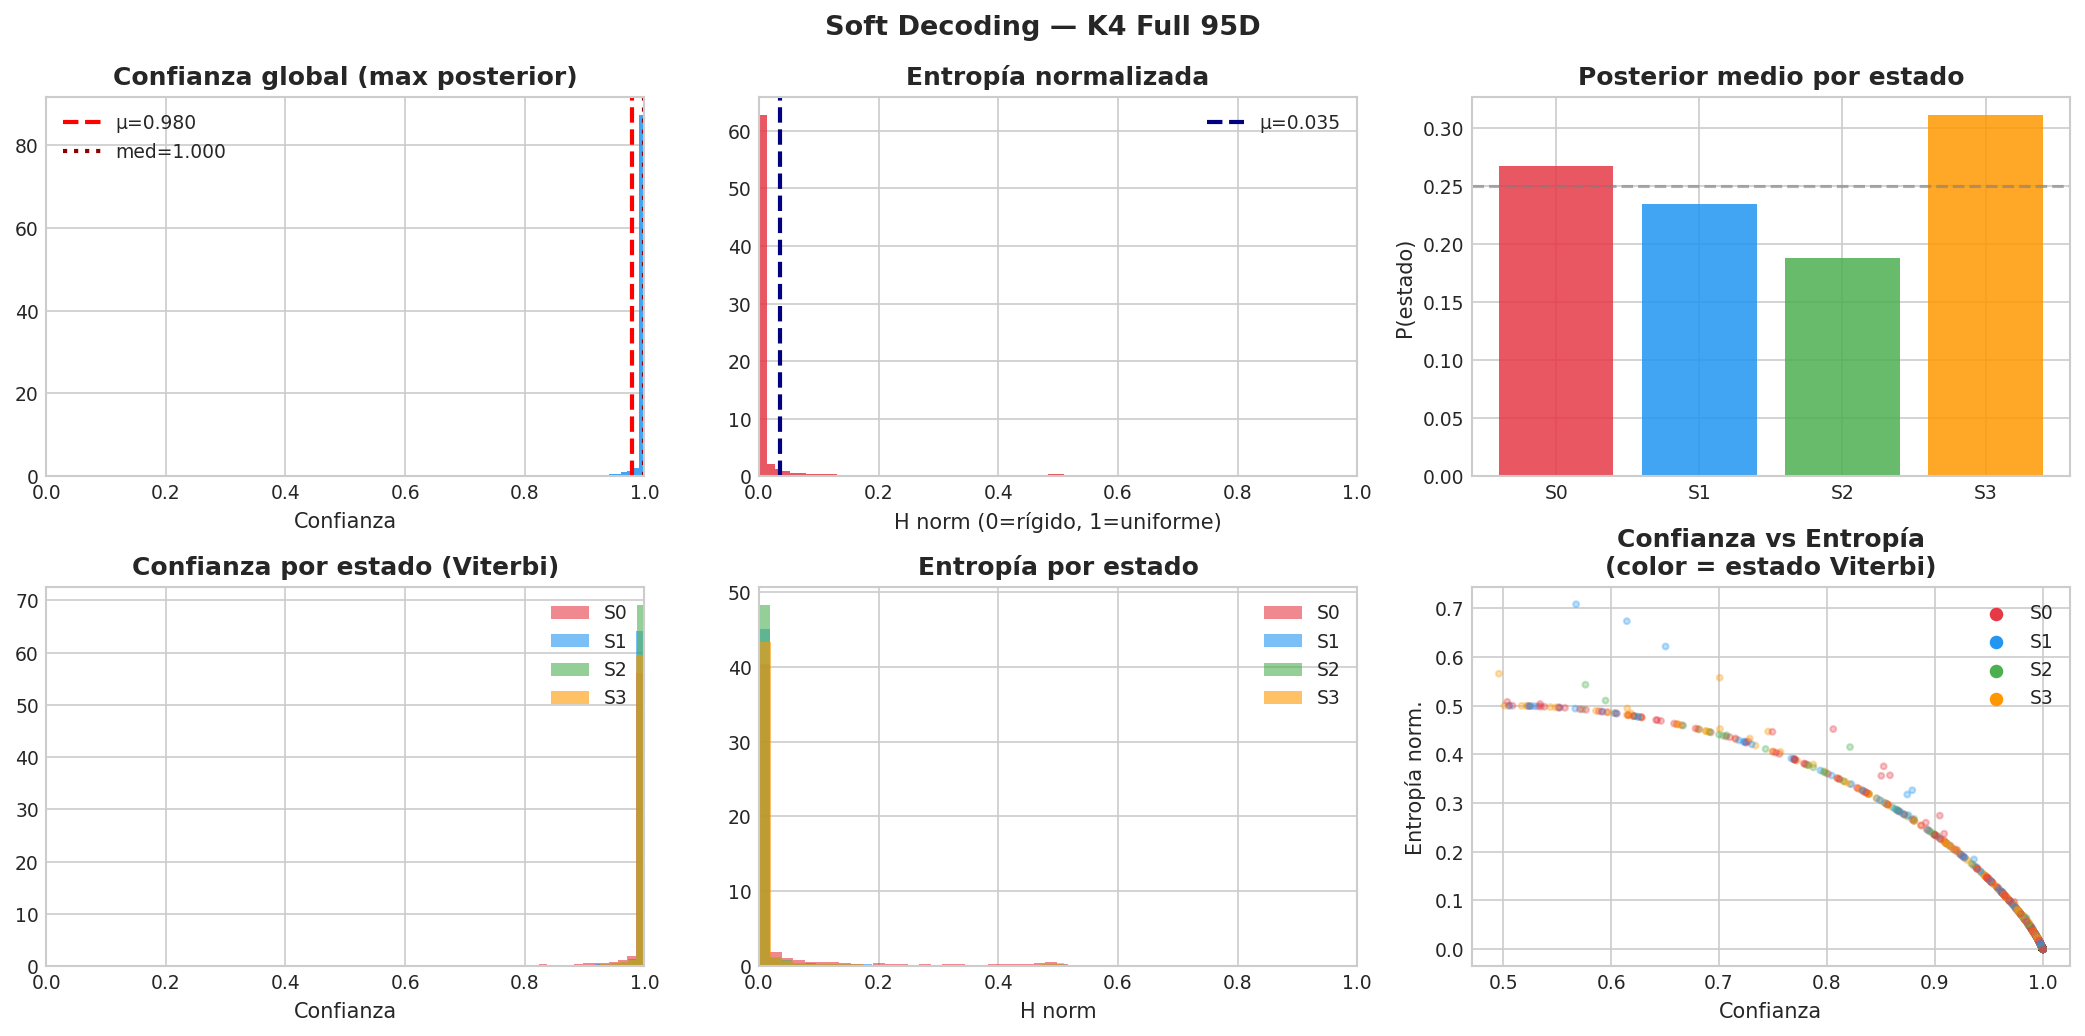


Confianza: μ=0.9800 | med=1.0000
Entropía:  μ=0.0351 | med=0.0000
Interpretación: Discreto


In [18]:
# ============================================================
# BLOQUE 6 — SOFT DECODING DETALLADO
# ============================================================

confidence = np.max(posterior, axis=1)
H          = -np.sum(posterior * np.log(posterior + 1e-12), axis=1)
H_norm     = H / np.log(N_STATES)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Confianza global
axes[0,0].hist(confidence, bins=60, color='#2196F3', alpha=0.85, density=True)
axes[0,0].axvline(np.mean(confidence), color='red', lw=2, linestyle='--',
                   label=f'μ={np.mean(confidence):.3f}')
axes[0,0].axvline(np.median(confidence), color='darkred', lw=2, linestyle=':',
                   label=f'med={np.median(confidence):.3f}')
axes[0,0].set_title('Confianza global (max posterior)', fontweight='bold')
axes[0,0].set_xlabel('Confianza')
axes[0,0].set_xlim(0,1); axes[0,0].legend()

# Entropía global
axes[0,1].hist(H_norm, bins=60, color='#E63946', alpha=0.85, density=True)
axes[0,1].axvline(np.mean(H_norm), color='navy', lw=2, linestyle='--',
                   label=f'μ={np.mean(H_norm):.3f}')
axes[0,1].set_title('Entropía normalizada', fontweight='bold')
axes[0,1].set_xlabel('H norm (0=rígido, 1=uniforme)')
axes[0,1].set_xlim(0,1); axes[0,1].legend()

# Posterior medio por estado
mean_post = posterior.mean(axis=0)
axes[0,2].bar([f'S{s}' for s in range(N_STATES)], mean_post,
               color=STATE_COLORS[:N_STATES], alpha=0.85)
axes[0,2].axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.6)
axes[0,2].set_title('Posterior medio por estado', fontweight='bold')
axes[0,2].set_ylabel('P(estado)')

# Confianza por estado asignado
for s in range(N_STATES):
    mask = (viterbi == s)
    if mask.sum() > 0:
        axes[1,0].hist(confidence[mask], bins=40, alpha=0.6,
                        color=STATE_COLORS[s], label=f'S{s}', density=True)
axes[1,0].set_title('Confianza por estado (Viterbi)', fontweight='bold')
axes[1,0].set_xlabel('Confianza'); axes[1,0].legend(); axes[1,0].set_xlim(0,1)

# Entropía por estado
for s in range(N_STATES):
    mask = (viterbi == s)
    if mask.sum() > 0:
        axes[1,1].hist(H_norm[mask], bins=40, alpha=0.6,
                        color=STATE_COLORS[s], label=f'S{s}', density=True)
axes[1,1].set_title('Entropía por estado', fontweight='bold')
axes[1,1].set_xlabel('H norm'); axes[1,1].legend(); axes[1,1].set_xlim(0,1)

# Scatter confianza vs entropía
sample = np.random.choice(len(viterbi), min(3000, len(viterbi)), replace=False)
scatter_colors = [STATE_COLORS[viterbi[i]] for i in sample]
axes[1,2].scatter(confidence[sample], H_norm[sample],
                   c=scatter_colors, alpha=0.3, s=8)
axes[1,2].set_xlabel('Confianza')
axes[1,2].set_ylabel('Entropía norm.')
axes[1,2].set_title('Confianza vs Entropía\n(color = estado Viterbi)', fontweight='bold')
for s in range(N_STATES):
    axes[1,2].scatter([], [], c=STATE_COLORS[s], label=f'S{s}', s=30)
axes[1,2].legend()

plt.suptitle(f'Soft Decoding — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('soft_decoding')
plt.show()

print(f"\nConfianza: μ={np.mean(confidence):.4f} | med={np.median(confidence):.4f}")
print(f"Entropía:  μ={np.mean(H_norm):.4f} | med={np.median(H_norm):.4f}")
interp = ('Discreto' if np.mean(confidence)>0.85 else
           'Metaestable' if np.mean(confidence)>0.65 else 'Continuo/mezclado')
print(f"Interpretación: {interp}")

---
## 5 — Heterogeneidad entre Sujetos

### ⚠️ Sujetos absorbentes (FO > 0.95 en un estado)

,Sujeto,Condición,Grupo,Estado,FO
0,AGOSINGO,GO,ADOLESCENTE,S3,0.9556
1,AGOSINNG,NOGO,ADOLESCENTE,S3,0.9833
2,BMPSCGO,GO,ADULTO,S0,0.9722
3,CGMSINGO,GO,ADULTO,S2,1.0000
4,CGMSINNG,NOGO,ADULTO,S2,0.9833
5,CJGSINGO,GO,ADULTO,S1,1.0000
6,CJGSINNG,NOGO,ADULTO,S1,1.0000
7,GGMSINNG,NOGO,ADULTO,S1,0.9833
8,IABWSCGO,GO,ADULTO,S3,0.9667
9,IABWSCNG,NOGO,ADULTO,S3,0.9778



Total: 18 sesiones con comportamiento absorbente
Estos sujetos pueden estar distorsionando los gaussianos de emisión.


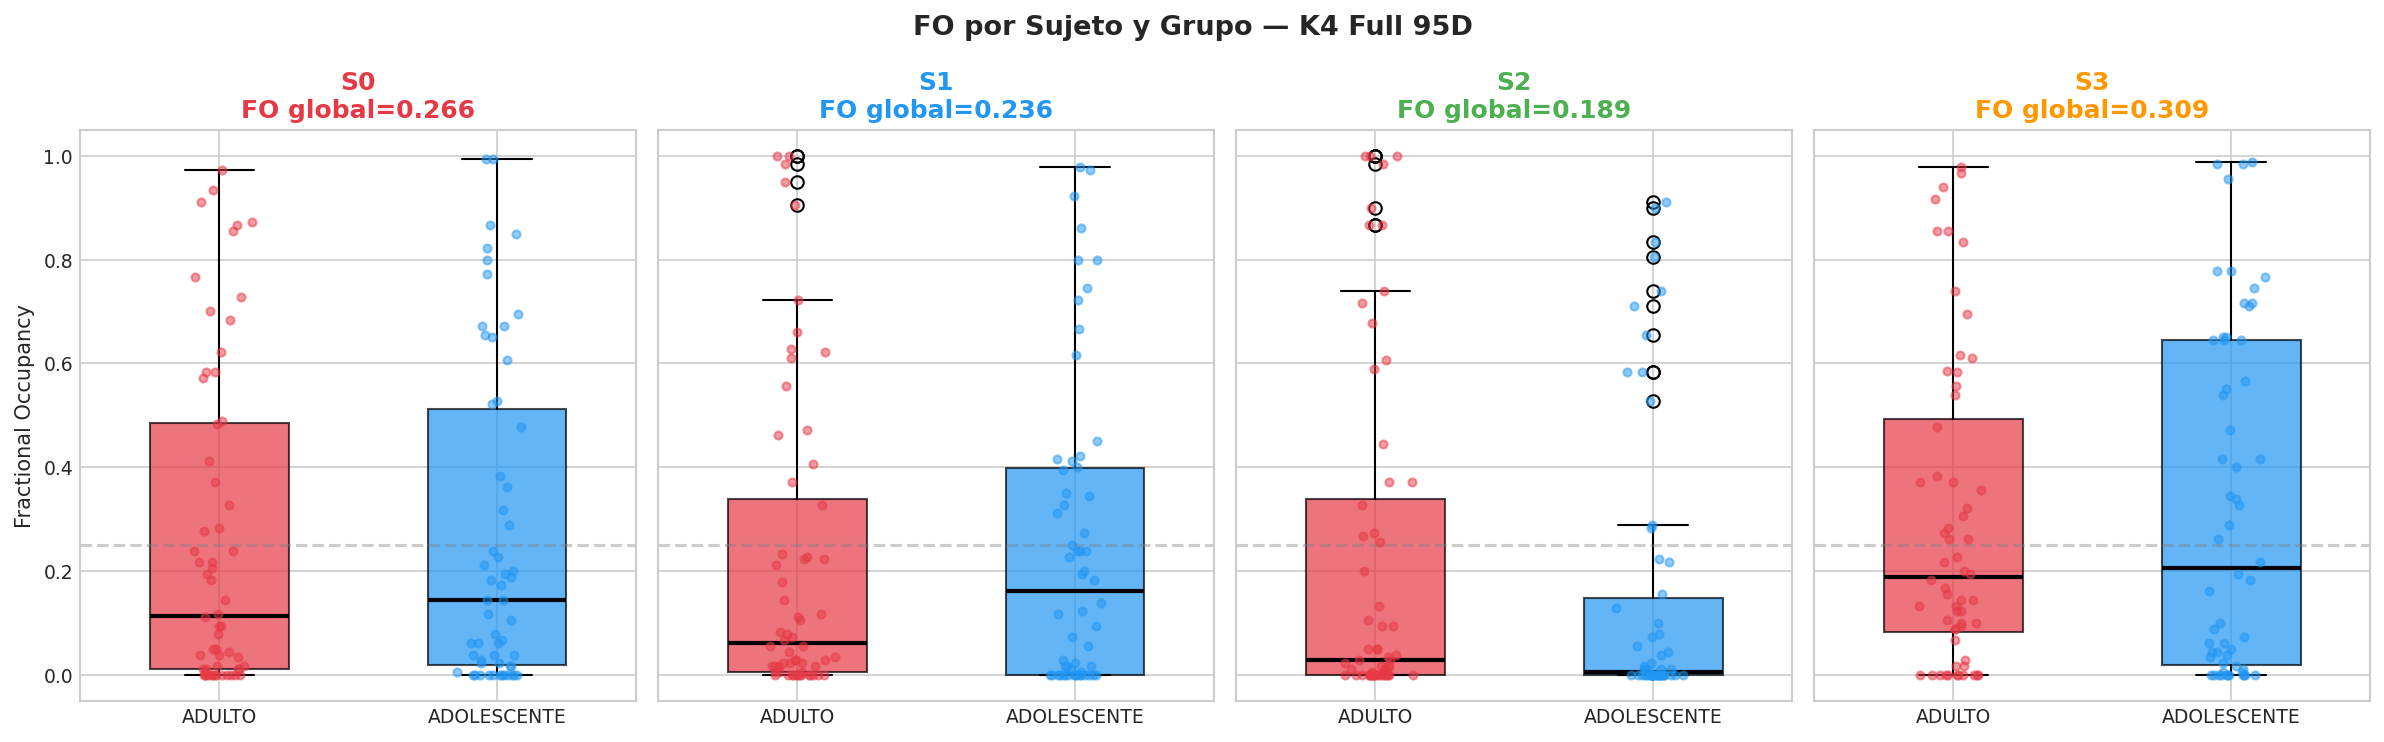


Variabilidad FO entre sujetos (std):
  S0: std=0.3067 | min=0.000 max=0.994
  S1: std=0.2977 | min=0.000 max=1.000
  S2: std=0.3045 | min=0.000 max=1.000
  S3: std=0.3105 | min=0.000 max=0.989


In [19]:
# ============================================================
# BLOQUE 7 — HETEROGENEIDAD ENTRE SUJETOS
# ============================================================

# Calcular FO por estado para cada sujeto/sesión
fo_matrix = np.zeros((len(subject_meta), N_STATES))
dwell_matrix = np.zeros((len(subject_meta), N_STATES))

for i, m in enumerate(subject_meta):
    v_sub = viterbi[m['start']:m['end']]
    p_sub = posterior[m['start']:m['end']]
    for s in range(N_STATES):
        fo_matrix[i, s] = np.mean(v_sub == s)

# Detectar sujetos absorbentes (FO > 0.95 en un estado)
absorbing = []
for i, m in enumerate(subject_meta):
    for s in range(N_STATES):
        if fo_matrix[i, s] > 0.95:
            absorbing.append({
                'Sujeto': m['subject_id'], 'Condición': m['condition'],
                'Grupo': m['group'], 'Estado': f'S{s}',
                'FO': round(fo_matrix[i, s], 4)
            })

if absorbing:
    display(Markdown("### ⚠️ Sujetos absorbentes (FO > 0.95 en un estado)"))
    display(pd.DataFrame(absorbing))
    print(f"\nTotal: {len(absorbing)} sesiones con comportamiento absorbente")
    print("Estos sujetos pueden estar distorsionando los gaussianos de emisión.")
else:
    print("✅ No se detectaron sujetos absorbentes (FO > 0.95)")

# Boxplot de FO por estado y grupo
fig, axes = plt.subplots(1, N_STATES, figsize=(4*N_STATES, 5), sharey=True)

groups_present = df_meta['group'].unique()
group_colors = {'ADULTO': '#E63946', 'ADOLESCENTE': '#2196F3', 'UNKNOWN': '#9E9E9E'}

for s, ax in enumerate(axes):
    data_by_group = {}
    for g in groups_present:
        idx_g = df_meta[df_meta['group'] == g].index.tolist()
        data_by_group[g] = fo_matrix[idx_g, s]

    positions = list(range(len(groups_present)))
    bp = ax.boxplot([data_by_group[g] for g in groups_present],
                     positions=positions, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     widths=0.5)
    for patch, g in zip(bp['boxes'], groups_present):
        patch.set_facecolor(group_colors.get(g, 'gray'))
        patch.set_alpha(0.7)

    # Puntos individuales
    for j, g in enumerate(groups_present):
        y = data_by_group[g]
        x = np.random.normal(j, 0.05, len(y))
        ax.scatter(x, y, alpha=0.5, s=15,
                    color=group_colors.get(g, 'gray'), zorder=3)

    ax.set_title(f'S{s}\nFO global={np.mean(fo_matrix[:, s]):.3f}',
                  fontweight='bold', color=STATE_COLORS[s])
    ax.set_xticks(positions)
    ax.set_xticklabels(groups_present, fontsize=9)
    ax.set_ylabel('Fractional Occupancy' if s == 0 else '')
    ax.axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.4)

plt.suptitle(f'FO por Sujeto y Grupo — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fo_by_subject')
plt.show()

# Variabilidad entre sujetos
print("\nVariabilidad FO entre sujetos (std):")
for s in range(N_STATES):
    print(f"  S{s}: std={fo_matrix[:,s].std():.4f} | "
          f"min={fo_matrix[:,s].min():.3f} max={fo_matrix[:,s].max():.3f}")

---
## 6 — Balance GO vs NOGO

BALANCE DE VENTANAS POR CONDICIÓN:
  GO   : 10,611 ventanas (50.0%) | 59 sesiones
  NOGO : 10,620 ventanas (50.0%) | 59 sesiones


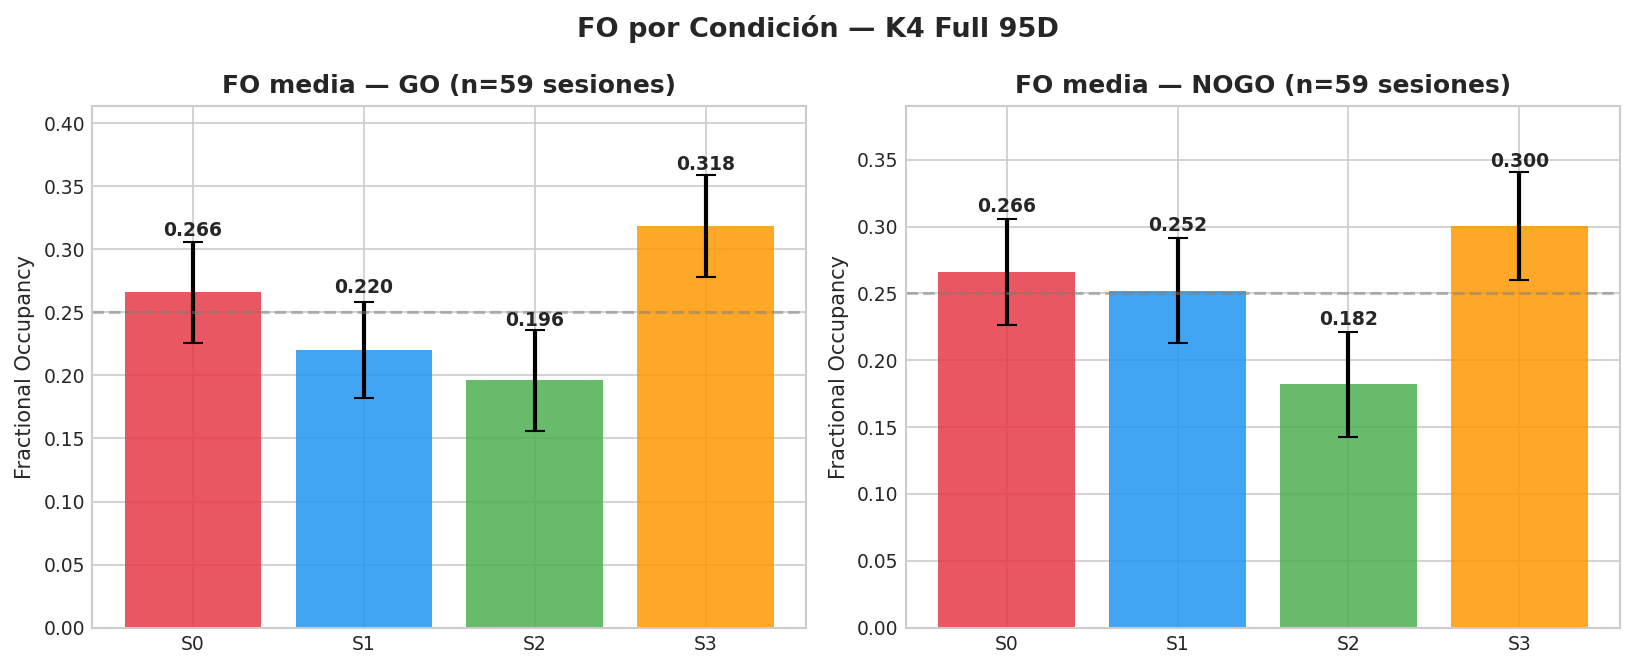


Ventanas por sesión GO:   min=171 max=180 med=180
Ventanas por sesión NOGO: min=180 max=180 med=180


In [20]:
# ============================================================
# BLOQUE 8 — BALANCE GO vs NOGO
# ============================================================

go_meta   = [m for m in subject_meta if m['condition'] == 'GO']
nogo_meta = [m for m in subject_meta if m['condition'] == 'NOGO']
unk_meta  = [m for m in subject_meta if m['condition'] == 'UNKNOWN']

n_go   = sum(m['n_windows'] for m in go_meta)
n_nogo = sum(m['n_windows'] for m in nogo_meta)
n_unk  = sum(m['n_windows'] for m in unk_meta)
n_total = len(viterbi)

print("BALANCE DE VENTANAS POR CONDICIÓN:")
print(f"  GO   : {n_go:,} ventanas ({100*n_go/n_total:.1f}%) | {len(go_meta)} sesiones")
print(f"  NOGO : {n_nogo:,} ventanas ({100*n_nogo/n_total:.1f}%) | {len(nogo_meta)} sesiones")
if n_unk > 0:
    print(f"  ⚠️  UNKNOWN: {n_unk:,} ventanas — revisa naming")

# FO por condición
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (cond, meta_list) in zip(axes, [('GO', go_meta), ('NOGO', nogo_meta)]):
    if not meta_list:
        ax.text(0.5, 0.5, f'Sin datos {cond}', ha='center', va='center',
                transform=ax.transAxes)
        continue

    fo_cond = np.zeros((len(meta_list), N_STATES))
    for i, m in enumerate(meta_list):
        v_sub = viterbi[m['start']:m['end']]
        for s in range(N_STATES):
            fo_cond[i, s] = np.mean(v_sub == s)

    means = fo_cond.mean(axis=0)
    sems  = fo_cond.std(axis=0) / np.sqrt(len(meta_list))
    x     = np.arange(N_STATES)

    bars = ax.bar(x, means, color=STATE_COLORS[:N_STATES], alpha=0.85,
                   yerr=sems, capsize=5, error_kw={'lw':2})
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+sems[int(bar.get_x())]+0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{s}' for s in range(N_STATES)])
    ax.set_title(f'FO media — {cond} (n={len(meta_list)} sesiones)', fontweight='bold')
    ax.set_ylabel('Fractional Occupancy')
    ax.set_ylim(0, min(1, means.max() * 1.3))

plt.suptitle(f'FO por Condición — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fo_by_condition')
plt.show()

# Ventanas por sujeto
win_go   = [m['n_windows'] for m in go_meta]
win_nogo = [m['n_windows'] for m in nogo_meta]
print(f"\nVentanas por sesión GO:   min={min(win_go) if win_go else 0} "
      f"max={max(win_go) if win_go else 0} "
      f"med={np.median(win_go) if win_go else 0:.0f}")
print(f"Ventanas por sesión NOGO: min={min(win_nogo) if win_nogo else 0} "
      f"max={max(win_nogo) if win_nogo else 0} "
      f"med={np.median(win_nogo) if win_nogo else 0:.0f}")

---
## 7 — Topomapas de Features por Estado

> Requiere MNE y `X_scaled` disponible (sin mismatch de features).

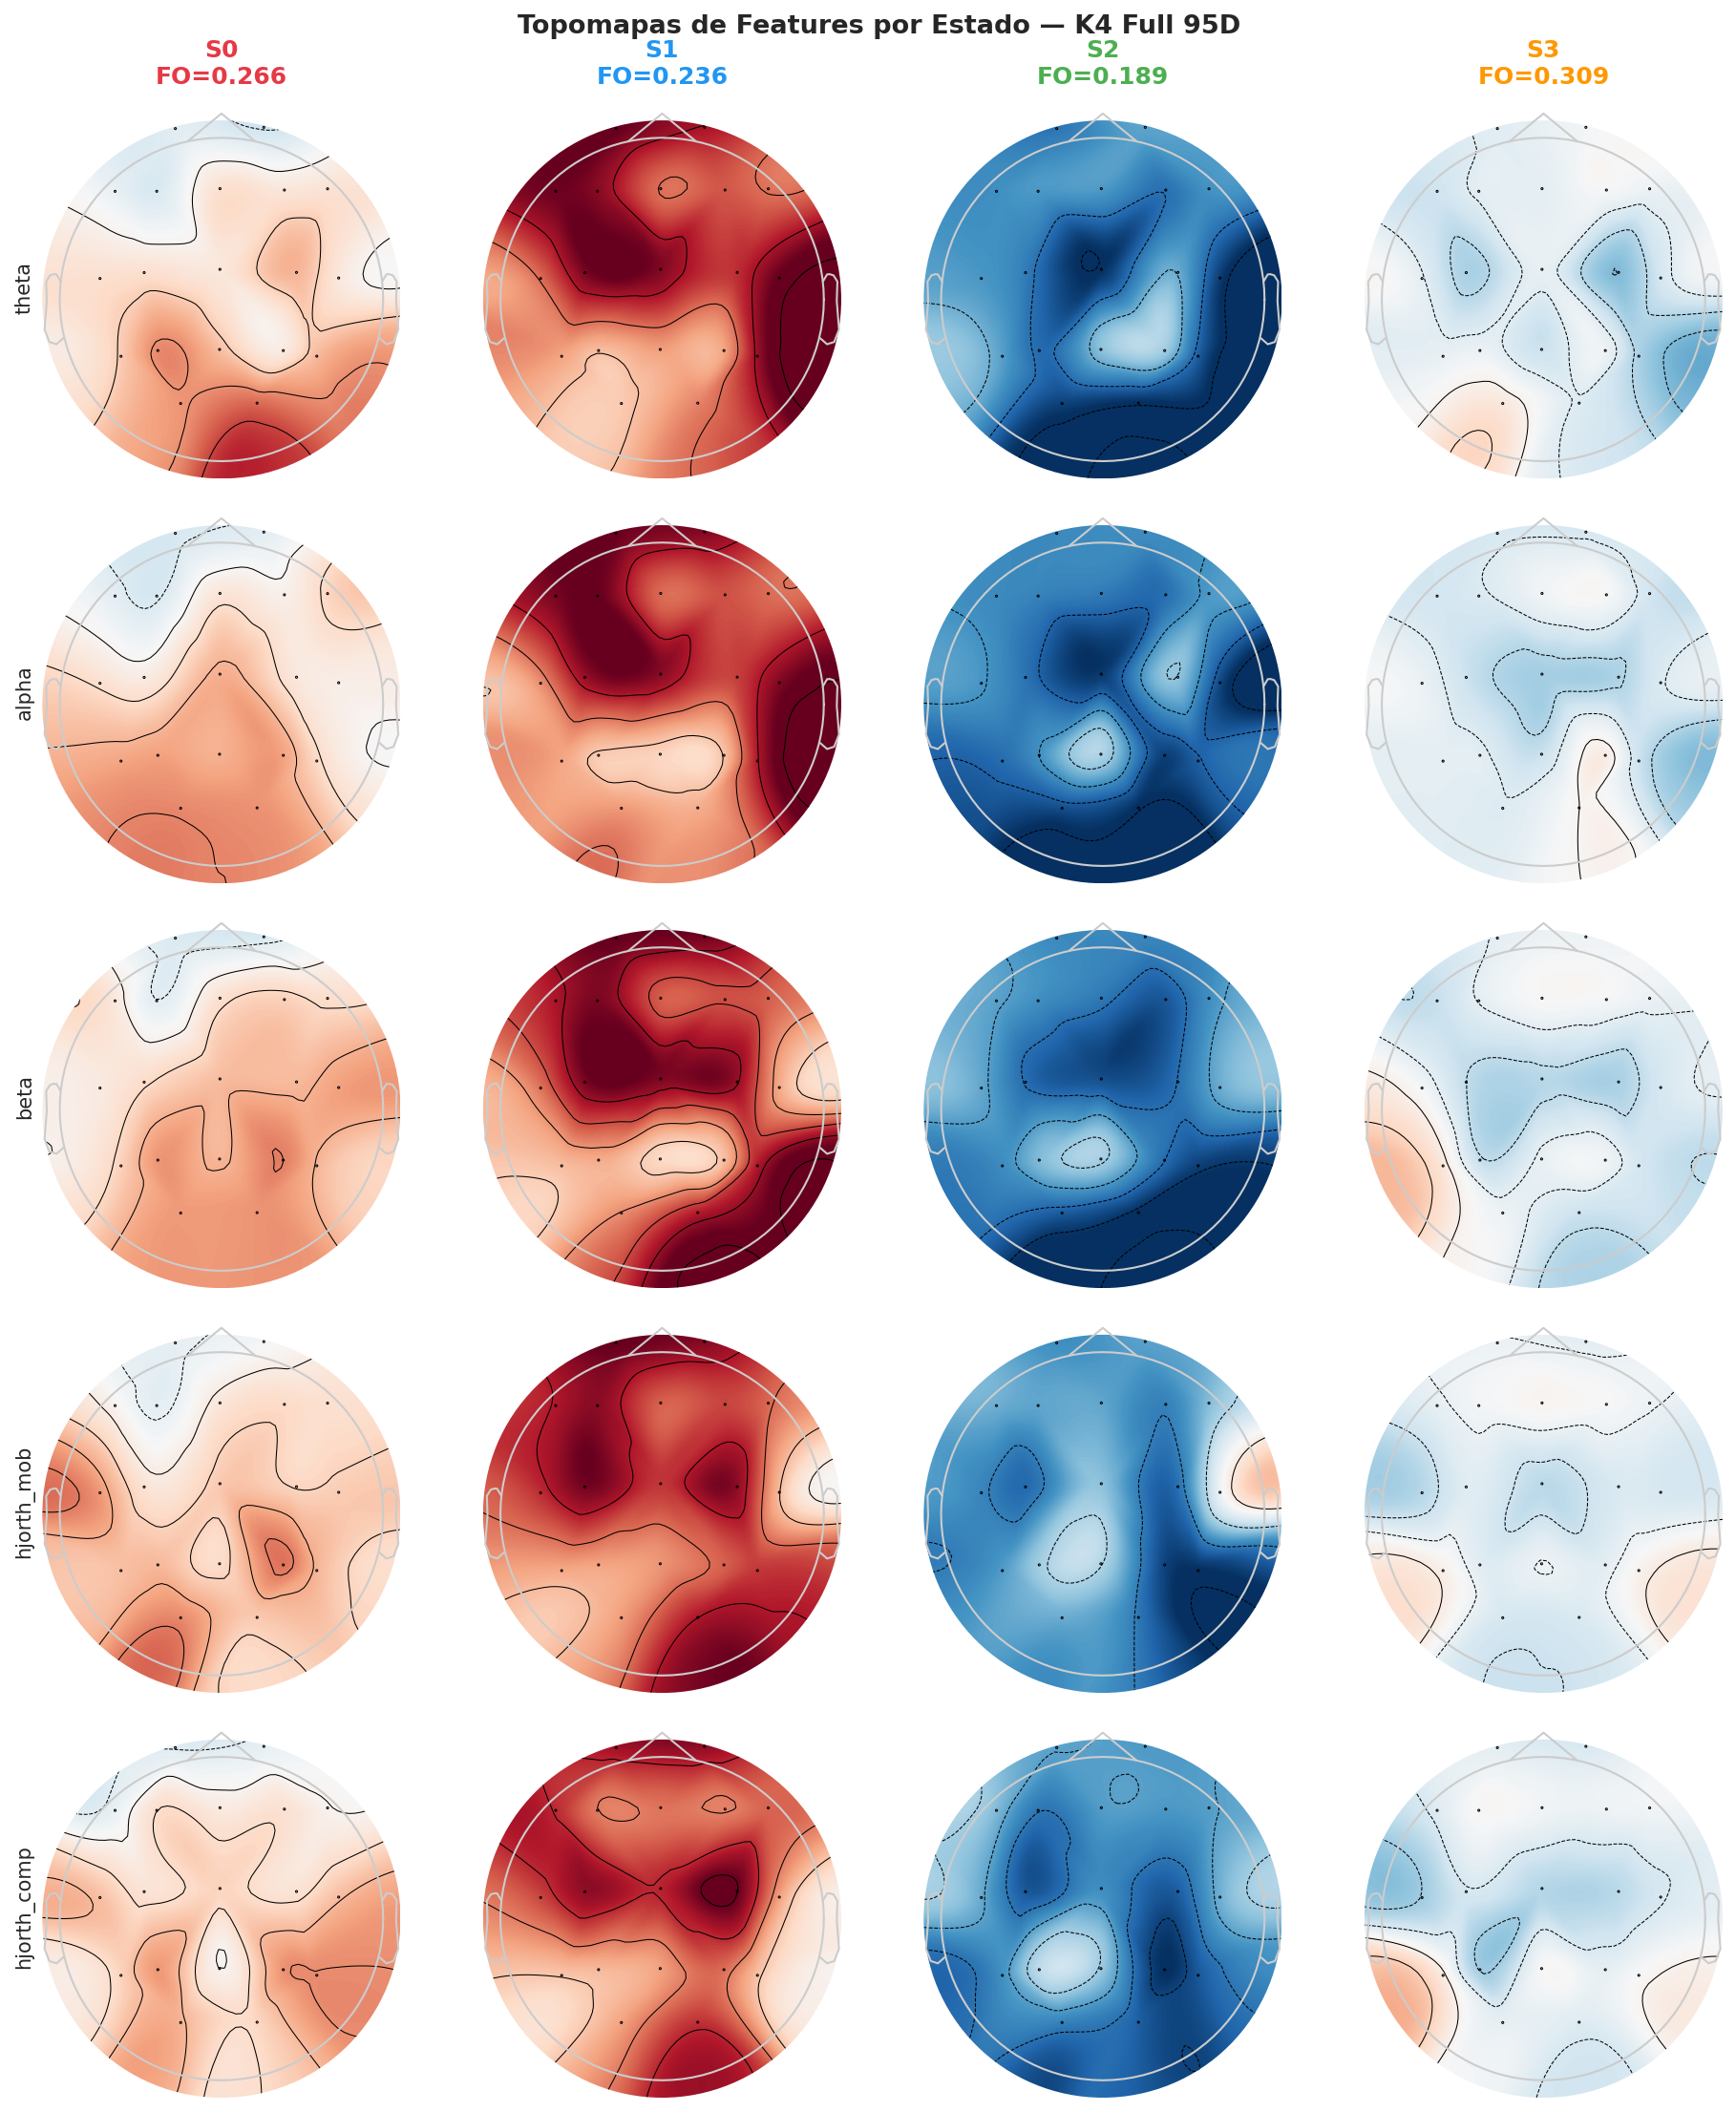


Media por feature y estado (espacio escalado):


,S0 (mean),S1 (mean),S2 (mean),S3 (mean)
Feature,,,,
theta,0.128200,0.605300,-0.678200,-0.157700
alpha,0.148100,0.597400,-0.703700,-0.153200
beta,0.176800,0.600000,-0.723400,-0.167800
hjorth_mob,0.137000,0.621300,-0.674100,-0.180000
hjorth_comp,0.154300,0.587400,-0.684500,-0.162600


In [21]:
# ============================================================
# BLOQUE 9 — TOPOMAPAS
# ============================================================

try:
    import mne
    MNE_OK = True
except ImportError:
    MNE_OK = False
    print("⚠️  MNE no disponible — pip install mne")

if not MNE_OK:
    print("Saltando topomapas.")
elif X_scaled is None:
    print(f"⚠️  X_scaled no disponible — revisa mismatch de features.")
else:
    n_feat_per_ch = n_actual // N_CHANNELS
    assert n_actual % N_CHANNELS == 0, \
        f"❌ {n_actual} features no divisible entre {N_CHANNELS} canales"

    info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=250, ch_types='eeg')
    info.set_montage('standard_1020')

    # Media por estado en espacio original
    state_means = np.array([
        X_scaled[viterbi == s].mean(axis=0) for s in range(N_STATES)
    ])

    # Una figura con todos los estados × todas las features
    fig, axes_t = plt.subplots(n_feat_per_ch, N_STATES,
                                figsize=(3.2*N_STATES, 3*n_feat_per_ch))
    if n_feat_per_ch == 1: axes_t = axes_t.reshape(1, -1)
    if N_STATES == 1:      axes_t = axes_t.reshape(-1, 1)

    for fi, feat_type in enumerate(FEATURE_TYPES[:n_feat_per_ch]):
        feat_idx = [c * n_feat_per_ch + fi for c in range(N_CHANNELS)]
        vmin = state_means[:, feat_idx].min()
        vmax = state_means[:, feat_idx].max()

        for s in range(N_STATES):
            ax_t = axes_t[fi, s]
            im, _ = mne.viz.plot_topomap(
                state_means[s, feat_idx], info, axes=ax_t,
                show=False, vlim=(vmin, vmax), cmap='RdBu_r', contours=4
            )
            if fi == 0:
                fo_s = np.mean(viterbi == s)
                ax_t.set_title(f'S{s}\nFO={fo_s:.3f}', fontweight='bold',
                                color=STATE_COLORS[s])
            if s == 0:
                ax_t.set_ylabel(feat_type, fontsize=10)

    plt.suptitle(f'Topomapas de Features por Estado — {EXP_LABEL}',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('topomaps')
    plt.show()

    # Tabla de medias por feature y estado
    print("\nMedia por feature y estado (espacio escalado):")
    rows_topo = []
    for fi, feat_type in enumerate(FEATURE_TYPES[:n_feat_per_ch]):
        feat_idx = [c * n_feat_per_ch + fi for c in range(N_CHANNELS)]
        row = {'Feature': feat_type}
        for s in range(N_STATES):
            row[f'S{s} (mean)'] = round(state_means[s, feat_idx].mean(), 4)
        rows_topo.append(row)
    display(pd.DataFrame(rows_topo).set_index('Feature')
              .style.background_gradient(cmap='RdBu_r', axis=1))

---
## 8 — Secuencia Temporal (muestra)

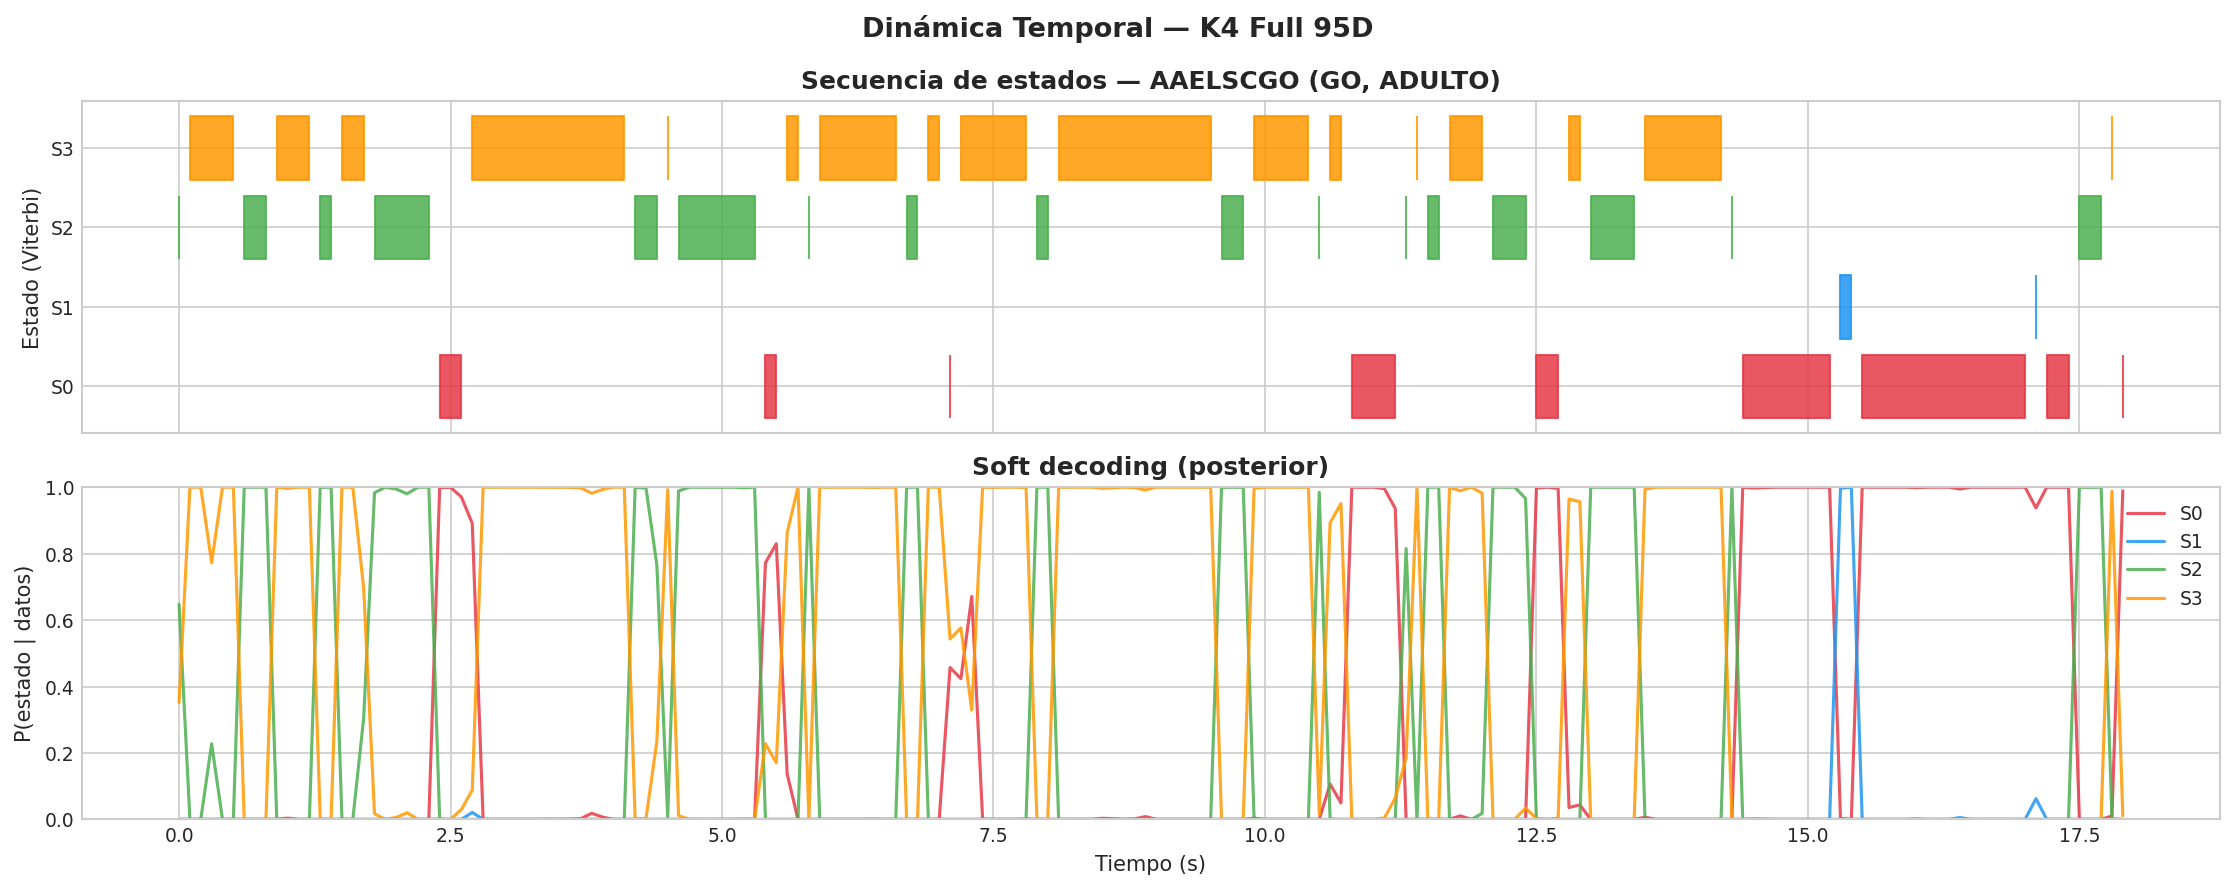

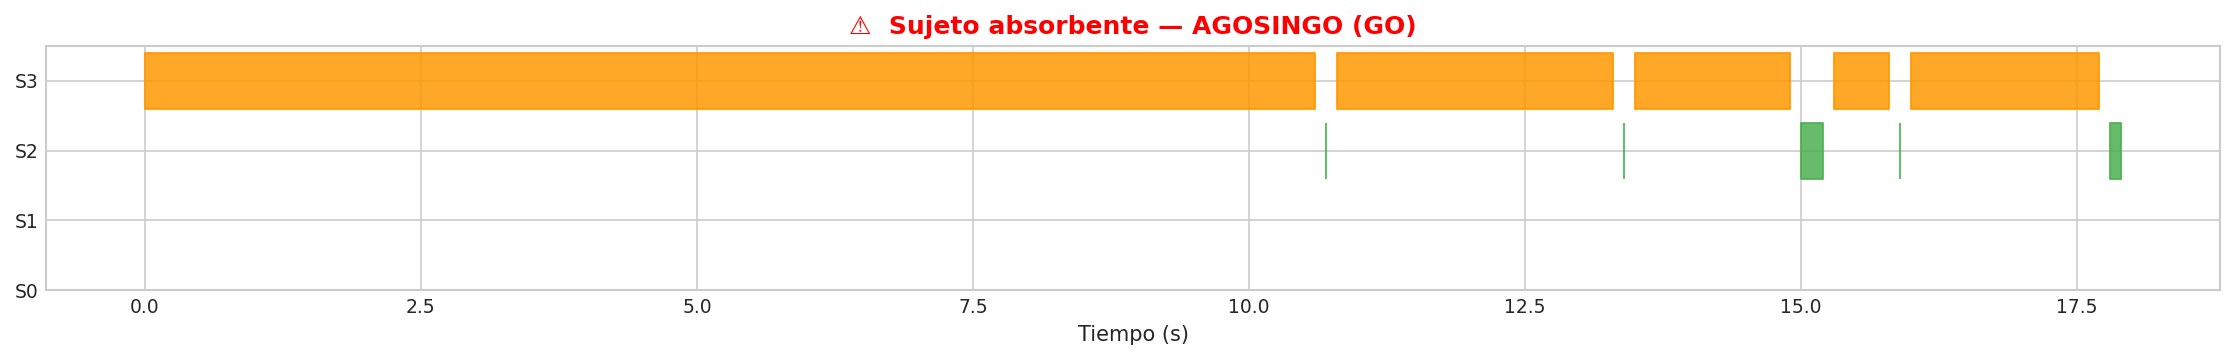

In [22]:
# ============================================================
# BLOQUE 10 — SECUENCIA TEMPORAL
# ============================================================

# Selecciona el sujeto con más variedad de estados
state_variety = []
for m in subject_meta:
    v_sub = viterbi[m['start']:m['end']]
    n_unique = len(np.unique(v_sub))
    state_variety.append(n_unique)

best_idx = int(np.argmax(state_variety))
best_sub = subject_meta[best_idx]
v_sub    = viterbi[best_sub['start']:best_sub['end']]
p_sub    = posterior[best_sub['start']:best_sub['end']]
t_sub    = np.arange(len(v_sub)) * STEP_MS / 1000  # en segundos

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# Panel superior: Viterbi
for s in range(N_STATES):
    mask = (v_sub == s)
    axes[0].fill_between(t_sub, s-0.4, s+0.4,
                          where=mask, color=STATE_COLORS[s], alpha=0.85)
axes[0].set_yticks(range(N_STATES))
axes[0].set_yticklabels([f'S{s}' for s in range(N_STATES)])
axes[0].set_ylabel('Estado (Viterbi)')
axes[0].set_title(f'Secuencia de estados — {best_sub["subject_id"]} '
                   f'({best_sub["condition"]}, {best_sub["group"]})',
                   fontweight='bold')

# Panel inferior: Posterior
for s in range(N_STATES):
    axes[1].plot(t_sub, p_sub[:, s], color=STATE_COLORS[s],
                  lw=1.5, alpha=0.85, label=f'S{s}')
axes[1].set_ylabel('P(estado | datos)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].set_title('Soft decoding (posterior)', fontweight='bold')

plt.suptitle(f'Dinámica Temporal — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('timeseries_sample')
plt.show()

# También muestra un sujeto absorbente si existe
absorbing_idx = [i for i, m in enumerate(subject_meta)
                  if any(fo_matrix[i,s] > 0.95 for s in range(N_STATES))]
if absorbing_idx:
    abs_sub = subject_meta[absorbing_idx[0]]
    v_abs   = viterbi[abs_sub['start']:abs_sub['end']]
    p_abs   = posterior[abs_sub['start']:abs_sub['end']]
    t_abs   = np.arange(len(v_abs)) * STEP_MS / 1000

    fig, ax = plt.subplots(figsize=(15, 2.5))
    for s in range(N_STATES):
        ax.fill_between(t_abs, s-0.4, s+0.4,
                         where=(v_abs==s), color=STATE_COLORS[s], alpha=0.85)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f'S{s}' for s in range(N_STATES)])
    ax.set_xlabel('Tiempo (s)')
    ax.set_title(f'⚠️  Sujeto absorbente — {abs_sub["subject_id"]} '
                  f'({abs_sub["condition"]})', fontweight='bold', color='red')
    plt.tight_layout()
    save_fig('timeseries_absorbing')
    plt.show()

---
## 9 — Diagnóstico Final

In [23]:
# ============================================================
# BLOQUE 11 — DIAGNÓSTICO FINAL
# ============================================================

print("="*60)
print(f"DIAGNÓSTICO — {EXP_LABEL}")
print("="*60)

checks = []

# 1. Pseudo-attractors
for s in range(N_STATES):
    dw = STEP_MS / max(1 - transmat[s,s], 1e-9)
    if transmat[s,s] > 0.97 or dw > 5000:
        checks.append(('❌', f'S{s} pseudo-atractor: self-trans={transmat[s,s]:.4f}, dwell={dw:.0f}ms'))
    else:
        checks.append(('✅', f'S{s} dwell plausible: {dw:.0f}ms'))

# 2. FO balance
fo_vals = [np.mean(viterbi==s) for s in range(N_STATES)]
fo_range = max(fo_vals) - min(fo_vals)
if min(fo_vals) < 0.10:
    checks.append(('❌', f'FO mínima < 10%: min={min(fo_vals):.3f}'))
else:
    checks.append(('✅', f'FO balance OK: rango={fo_range:.3f}'))

# 3. Confianza
mean_conf = np.mean(np.max(posterior, axis=1))
if mean_conf > 0.80:
    checks.append(('✅', f'Confianza alta: {mean_conf:.4f}'))
elif mean_conf > 0.60:
    checks.append(('⚠️ ', f'Confianza moderada: {mean_conf:.4f}'))
else:
    checks.append(('❌', f'Confianza baja: {mean_conf:.4f}'))

# 4. Sujetos absorbentes
n_absorbing = len(absorbing_idx) if 'absorbing_idx' in dir() else 0
if n_absorbing == 0:
    checks.append(('✅', 'Sin sujetos absorbentes'))
elif n_absorbing <= 3:
    checks.append(('⚠️ ', f'{n_absorbing} sujeto(s) absorbente(s) — considerar exclusión'))
else:
    checks.append(('❌', f'{n_absorbing} sujetos absorbentes — problema sistemático'))

# 5. Balance GO/NOGO
if n_go > 0 and n_nogo > 0:
    ratio = max(n_go, n_nogo) / min(n_go, n_nogo)
    if ratio < 1.3:
        checks.append(('✅', f'Balance GO/NOGO: {n_go}/{n_nogo} (ratio={ratio:.2f})'))
    else:
        checks.append(('⚠️ ', f'Desbalance GO/NOGO: {n_go}/{n_nogo} (ratio={ratio:.2f})'))

for icon, msg in checks:
    print(f"  {icon}  {msg}")

n_ok = sum(1 for icon, _ in checks if icon == '✅')
n_warn = sum(1 for icon, _ in checks if icon == '⚠️ ')
n_fail = sum(1 for icon, _ in checks if icon == '❌')
print(f"\nResumen: {n_ok} OK | {n_warn} avisos | {n_fail} críticos")

if n_fail == 0 and n_warn <= 1:
    print("\n⭐ EXPERIMENTO APTO PARA REPORTE")
elif n_fail == 0:
    print("\n✅ ACEPTABLE — revisar avisos antes de reportar")
else:
    print("\n❌ REQUIERE CORRECCIÓN antes de reportar")

DIAGNÓSTICO — K4 Full 95D
  ✅  S0 dwell plausible: 697ms
  ✅  S1 dwell plausible: 546ms
  ✅  S2 dwell plausible: 831ms
  ✅  S3 dwell plausible: 677ms
  ✅  FO balance OK: rango=0.120
  ✅  Confianza alta: 0.9800
  ❌  18 sujetos absorbentes — problema sistemático
  ✅  Balance GO/NOGO: 10611/10620 (ratio=1.00)

Resumen: 7 OK | 0 avisos | 1 críticos

❌ REQUIERE CORRECCIÓN antes de reportar
